In [ ]:
# 이전까지는 "지도학습"으로 감독관이 있는 학습이었다. -> 레이블이 있는 학습
# 그래서 특성 데이터(= feature data, 독립변수) 를 기반으로
# y라는 타겟(= 레이블, 종속변수)을 예측하는 것이다.

# 즉, 지도학습은 예측에 대한 문제였다.

# 비지도 학습은 감독자(정답)가 없는 학습이다. -> 레이블이 없는 학습
# X의 특징과 패턴만 파악할 수 있다 예측할 목표인 y는 없음
# 비지도학습에서 가장 많이 하는 방법은 군집분석 (Clustering)이다.

# Clustering 태블로하면서 한번 접해봄

# Clustering(군집분석)
- 주어진 데이터들을 특성에 따라 유사한 것끼리  묶음으로써 각 유형별 특징을 분석하는 기법
- 비지도학습으로 레이블 정보를 학습과정에서 이용하지 않음
- 분류분석과 동일하게 데이터는 하나의 군집에 할당됨
- 같은 군집 내 데이터들의 거리를 최소화하거나 다른 군집간의 거리를 최대화하는 군집을 형성
    - 거리계산은 유클리드거리(직선거리)가 보편적으로 사용됨
- 거리만 잘 적용되면 모든 유형의 데이터에 적용이 가능하나 거리와 가중치 정의가 어렵고 해석이 어려운 단점이 있음

In [ ]:
# 군집은 거리를 기반으로 만드는데
# KNN과 구분할 것
# KNN 할 때 거리를 기반으로 분류했음 : 가까운 k개 이웃 기반 분류
# 이때는 k개 이웃중 많은 결과를 통계내어 결과로 도출했다.

## 군집 방법론
- 계층적(Hierarchical) 방법
    - 가까운 개체끼리 차례로 묶거나 멀리 떨어진 개체를 차례로 분리해 가는 군집 방법
    - 한 번 군집에 할당된 객체는 다시 분리되지 않는 것이 특징
    - 비계층적 방법에 비해 계산량이 많고 시간이 오래 걸림

- 비계층적(Non Hierarchical) 방법
    - 랜덤으로 데이터를 군집화하고 군집 과정에서 값의 변화에 따라 각 데이터들을 적절한 군집으로 이동시키면서 분리해가는 군집 방법


In [ ]:
# 랜덤하게 중심점을 찍어서 각각의 데이터를 거리에 따라 묶음
# 이동에 따라 계속 군집이 조금씩 바뀜

## K-Mean
- 비지도 학습 기반의 대표적인 비계층적 군집 알고리즘
- 사전에 정의된 군집수 K개로 데이터를 분할
    - 데이터는 K개의 군집 중심에서 가장 가까운 군집에 할당
    - 군집의 중심점과 데이터 간의 거리를 계산하기 때문에 계층적 군집 알고리즘에 비해 계산량이 적음
- 최적의 군집수 K를 정의하는 것이 많이 어려움
- 군집 형성 과정
    1. 랜덤하게 K개(사전의 정의)의 중앙점을 지정
    2. 유클리드 거리를 이용하여 군집의 중심점과의 거리 계산 및 가장 거리가 가까운 군집으로 군집 할당
    3. 군집 내 데이터의 평균을 계산 후 새로운 중심점으로 배정 및 중심점이 더 이상 이동 하지 않을 때까지 반복

    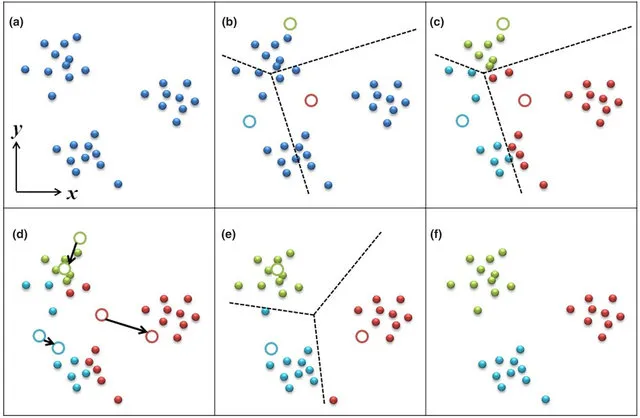

```
sklearn.cluster.KMeans(n_clusters, init,..)
```
- `n_clusters` : 군집의 개수(k)
- `init` : 초기 중심점 설정 방법
    - 'k-means++'(기본값): 확률적 기법을 이용하여 선택, 멀리 떨어진 포인트 선택확률이 높음
    - 'random' : 랜덤으로 설정
- `cluster_centers_` : 학습된 중심점의 위치 정보


In [ ]:
# k-means : k의 개의 중심점이 있고 클러스터가 k개이다.
#           그래서 그룹의 개수가 k
# KNN     : 분류한 그룹의 개수는 k개가 아니라 전체데이터셋의 라벨의 개수이다 (class가 3개면 3개)
#           k는 그냥 이웃의 개수이다.

In [ ]:
# k-means의 k를 자동으로 구해주는 알고리즘도 있지만
# k-means는 별도로 k를 지정해주어야한다
# k가 커지면 커질수록 decision tree에 비유하면 너무 많은 나뭇가지들이 생긴다고 볼 수 있다.
# 성능평가시 전처럼(y-y`)^2 를 해줄 수 없다 (예측값 y`가 없으므로)

#### [예제1] make_blobs()
- `make_blobs()`함수를 사용하여 랜덤데이터 생성
    - 특성의 개수(n_features), 군집의 개수(centers), 샘플의 수(n_samples)를 설정하여 랜덤한 데이터 생성

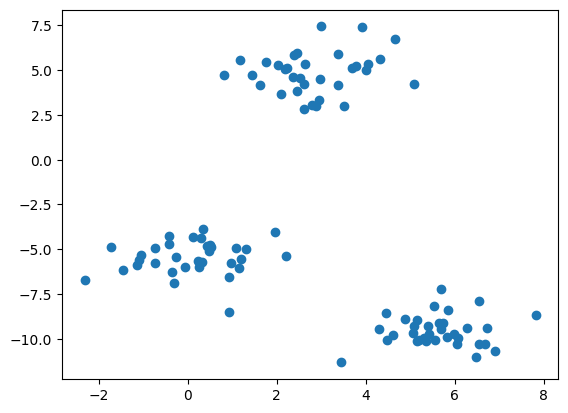

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X,y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=10)
plt.scatter(X[:,0], X[:,1])

In [23]:
# K-means 모델 학습
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
# kmeans.fit_predict(X) # 학습하고 바로 예측하게 할 수도 있다.

KMeans(n_clusters=3)

In [24]:
# 학습된 중심점의 위치
print(kmeans.cluster_centers_)

[[ 0.08921213 -5.46441742]
 [ 2.84050716  4.85840422]
 [ 5.6183469  -9.54288499]]


In [25]:
# 만들어낸 라벨 확인
labels = kmeans.labels_
print(labels)

[0 0 1 2 1 1 2 0 1 2 2 1 1 0 0 1 2 1 2 1 2 0 1 0 2 1 1 1 1 2 0 1 1 2 0 0 0
 1 1 1 0 2 0 0 1 2 2 2 0 2 1 0 2 2 0 2 1 0 2 2 1 1 0 0 0 2 2 0 0 0 1 2 1 1
 0 1 1 0 2 2 2 1 2 1 0 1 0 2 0 0 2 2 2 0 0 0 1 2 2 2]


In [26]:
labels = kmeans.predict(X)
print(labels)

[0 0 1 2 1 1 2 0 1 2 2 1 1 0 0 1 2 1 2 1 2 0 1 0 2 1 1 1 1 2 0 1 1 2 0 0 0
 1 1 1 0 2 0 0 1 2 2 2 0 2 1 0 2 2 0 2 1 0 2 2 1 1 0 0 0 2 2 0 0 0 1 2 1 1
 0 1 1 0 2 2 2 1 2 1 0 1 0 2 0 0 2 2 2 0 0 0 1 2 2 2]


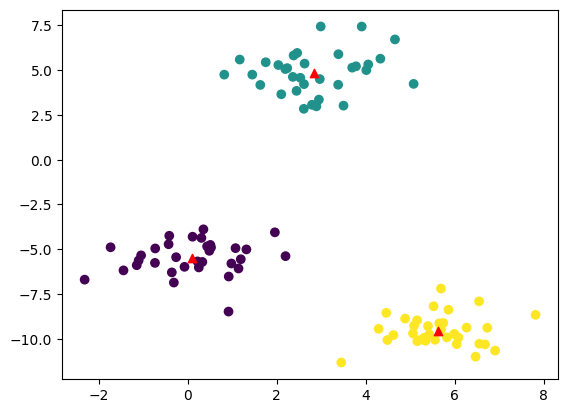

In [29]:
# 학습된 결과 시각화
# 세모가 중심점
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c='r', marker='^')

#### [예제2] make_moons()
- `make_moons()`함수를 사용하여 랜덤데이터 생성
    - 특성의 개수(n_features), 노이즈(noise), 샘플의 수(n_samples)를 설정하여 랜덤한 데이터 생성

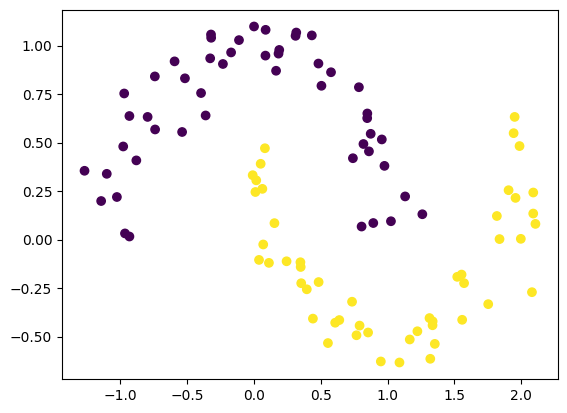

In [3]:
from sklearn.datasets import make_moons

X,y = make_moons(n_samples=100, noise=0.1, random_state=10)
plt.scatter(X[:,0], X[:,1], c=y)

In [34]:
# 모델 학습
kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(X)

In [ ]:
# 시각화
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0])

# 분리를 달모양으로 분리하고 싶었지만 하지 못한 모습을 볼 수 있다.
# kmeans는 선형으로 경계를 만들어주지만 동그란(?) 달모양으로 나눌 수 없다. 밑을 읽어보자

### K-Means 군집경계
- K-Means 군집 간의 경계는 선형적으로 복잡한 경계를 갖는 경우 올바르게 군집화할 수 없음
- Spectral Clustering, DBSCAN과 같은 다른 군집 방법을 이용하여 올바르게 군집 가능

In [ ]:
# 밀도기반의 군집을 만들 수 있음 ↓

## DBSCAN(Density-Based Spatial Clustering of Applications with Noise)
- K-Means 군집의 경우 군집 간의 거리를 이용하기 때문에 선형적인 결정 경계를 가짐
    - DBSCAN의 경우 밀도 기반의 클러스터링으로 점들이 몰려 있어서 밀도가 높은 부분을 군집화하는 방식
    - 한 점을 기준으로 반경 거리(eps) 안에 점이 n개 이상 있으면 하나의 군집으로 인식
    - 해당 조건이 성립하지 않는 점의 경우 noise로 분류
- 클러스터의 개수를 미리 지정할 필요 없음
- 복잡한 형상도 찾을 수 있으며, 어떤 클래스에서 속하지 않는 포인트를 구분할 수 있음
- 병합군집이나 K-Means 보다는 느리지만 비교적 큰 데이터셋에도 적용 가능
- 군집 형성 과정
    1. 특정 점에서 반경 거리(ɛ, eps) 안에 있는 점의 수를 확인
        - 만약 점의 수가 군집 형성 최소 개수(min_samples)보다 크다면 군집으로 할당
    2. 군집에 할당된 점에서 반경 거리(eps) 안에 있는 모든 점을 같은 군집으로 할당
    3. 어떤 점을 중심으로 하여도 군집 형성 조건에 속하지 않는 점의 경우 노이즈로 분류 (클러스터=-1)

    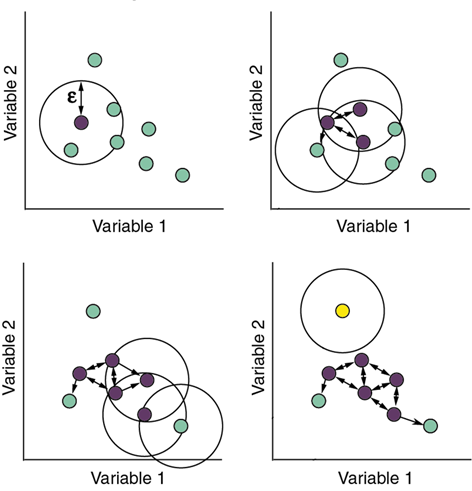

```
sklearn.cluster.dbscan
```
- `eps` : 반경 거리 지정 (기본값 0.5)
- `min_samples` : 군집형성 최소 개수 (기본값 5)
- `metric` : 거리 측정 방식 (기본값 euclidean)
    - euclidean, manhattan, minkowski, chebyshev 등


In [ ]:
# 별도로 클러스터의 개수(n_clusters)를 지정해주지 않고
# 반경거리와 미니멈 샘플의 개수를 지정해주어야한다.

In [6]:
# DBSCAN 클러스터링
from sklearn.cluster import DBSCAN

dbscan = DBSCAN()
labels = dbscan.fit_predict(X)
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

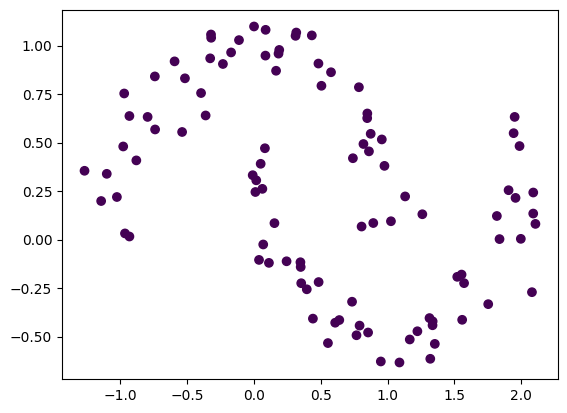

In [74]:
# DBSCAN 결과 시각화
plt.scatter(X[:,0], X[:,1], c=labels)

- 모든 데이터가 하나의 군집으로 지정
    - min_samples 또는 eps 값의 조절이 필요하지만 최우선적으로는 표준화를 적용
    - DBSCAN의 경우 밀도를 기반으로 하기 때문에 데이터 스케일에 영향이 있음

In [4]:
# StandardScaler를 이용하여 표준화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

array([0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0])

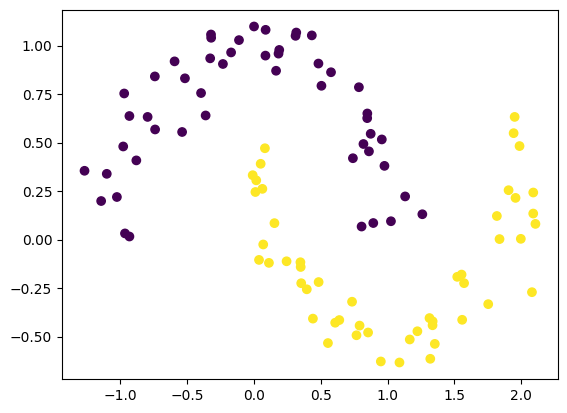

In [7]:
# 표준화된 데이터 클러스터링 및 시각화
z_labels = dbscan.fit_predict(X_scaled)
plt.scatter(X[:,0], X[:,1], c=z_labels)
z_labels

In [ ]:
# 그럼 어떻게 평가할까?

## 군집알고리즘 평가
- 군집 알고리즘의 경우 비지도학습으로 실제값을 기준으로 하여 성능을 평가할 수 없음
- 군집 내의 응집도(cohesion)와 군집 간 분리도(separation)를 기반으로 성능 평가
- 실제 레이블이 존재하는 경우 정확도(Accuracy), ARI(Adjusted Rand Index) 또는 NMI(Normalized Mutual Information)를 이용하여 평가
    - 군집의 번호는 랜덤하게 배정되기 때문에 위치의 값을 비교하는 정확도는 성능이 부정확하게 나올 수 있음

### 성능평가 지표
- 정확도(Accuracy) : 전체 데이터 중에 올바르게 분류한 비율 <br>
$Accuracy = \frac{TP+TN}{TP+FN+FP+TN}$ <br>
`sklearn.metrics.accuracy_score`
- ARI(Adjusted Rand Index) : Rand Index를 정규화하여 무작위 군집화의 효과를 보정한 지표[-1,1]
    - Rand Index : 군집화된 데이터와 실제 레이블간의 유사도를 평가, 같은 군집에 분류되었는지를 기반으로 평가 [0,1]
    -
$ARI = \frac{RI - E[RI]}{max(RI) - E[RI]}$
    - 1 : 완벽히 일치, 0 : 우연히 일치, -1 : 반대로 예측
`sklearn.metrics.cluster.adjusted_rand_score`
- NMI(Normalized Mutual Information) : 군집화된 데이터와 실제 레이블간의 상호 정보(Mutual Information)를 정규화하여 계산
    - 상호 정보 (Mutual Information, MI): 군집화 결과와 실제 레이블 간의 의존도 지표 <br>
$MI(y, \hat{y}) = \sum\sum p(y,\hat{y})log(\frac{p(y)p(\hat{y})}{p(y,\hat{y})})$
    - NMI : MI를 정규화 [0,1] <br>
$NMI(y, \hat{y}) = \frac{MI(y, \hat{y})}{\sqrt{entropy(y)entropy(\hat{y})}}$ <br>
`sklearn.metrics.cluster.normalized_mutual_info_score`
- Silhouette Score(실루엣 지표) : 각 데이터가 얼마나 잘 군집되었는지, 다른 군집과 얼마나 잘 분리되어 있는지를 측정 [-1,1] <br>
$s= \frac{b-a}{max(a,b)}$
    - a : 동일 군집내 데이터간 평균 거리, b:다른 군집과의 평균거리
```sklearn.metrics.cluster.silhouette_score```
- Inertia (이너샤, Sum of Squared Distances) : 각 군집 내의 데이터와 군집 중심 간의 거리 제곱의 합으로 군집의 응집도 평가 <br>
```<클러스터링모델>.inertia_```


### 적정 K값 선정
- K값에 따른 실루엣지표, 이너샤의 변화를 확인하여 최적의 K값 선정

####[예제] wine데이터를 이용한 클러스터링

In [51]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import *
# 데이터 추출
wine = load_wine()

# 비지도학습은 레이블이 없으므로 일반적으로 데이터를 분할하여 학습/평가하지 않음
# train/test 나누는 이유가 모델이 얼마나 정확한지 확인하고자 하기 위함인데
# 비지도학습의 경우 무엇이 확실한 정답이다! 할 수 없기 때문에 나누지 않는다
# 군집 분석은 얼마나 잘 분리해냈느냐 정도의 성능평가이다.

# 여기서 새로운 데이터를 가져오면 다시 학습하고 다시 특징을 파악하는 수밖에 없다.

# Kmeans 모델 학습
kmeans = KMeans(n_clusters=3)

# 클러스터링 결과 저장
labels= kmeans.fit_predict(wine.data) # 패턴파악위해 별도로 나누지 않고 wine.data 그대로 가져온다.
labels
# 성능 평가
print("Accuracy:", accuracy_score(wine.target, labels))
# accuracy는 타겟과 동일한 형태로 라벨이 나누어지지 않기 때문에 낮을 수 밖에 없다
# 밑의 결과가 보정된 결과이다(조금 낮지만)
print("ARI:", adjusted_rand_score(wine.target, labels))
print("NMI:", normalized_mutual_info_score(wine.target, labels))
print("Sihouette score:", silhouette_score(wine.data, labels))
print("Inertia:", kmeans.inertia_)

Accuracy: 0.16853932584269662
ARI: 0.37111371823084754
NMI: 0.4287568597645355
Sihouette score: 0.5711381937868838
Inertia: 2370689.6867829696


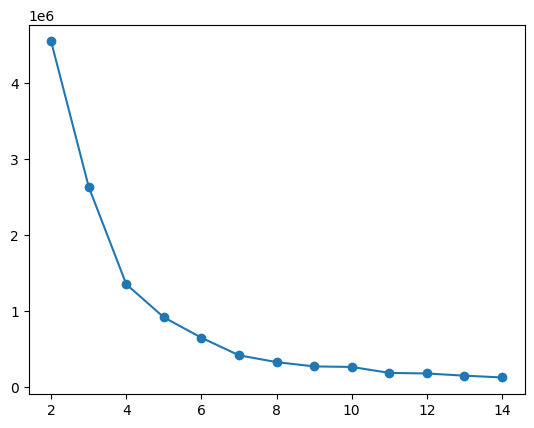

In [53]:
# Inertia 기반 적정 K 찾기
k_range = range(2,15)
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(wine.data)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o')

# inertia_는 군집의 응집도(k가 많으면 많을 수록 군집의 거리가 짧아지는 것은 당연한 이야기)
# k가 크면 클수록 좋아보이지만 잘 군집화했다고 볼 수는 없음
# 그래서 밑에서 실루엣 스코어 기반의 적정 k를 찾아보겠다.

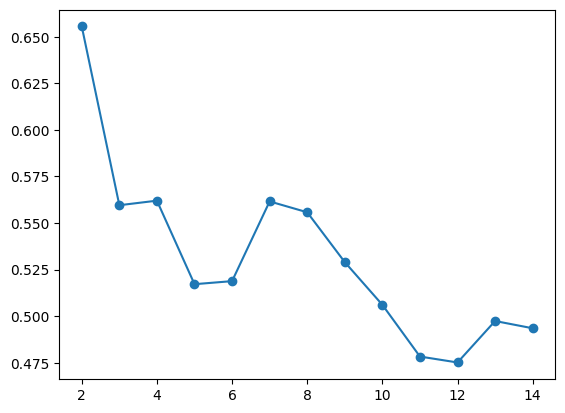

In [55]:
# 실루엣 스코어 기반 적정 K 찾기
s_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(wine.data)
    s_scores.append(silhouette_score(wine.data, labels))

plt.plot(k_range, s_scores, marker='o')

# 데이터들이 뭉쳐있으니까 두개로 해야지 평균 거리가 좀 넓어져 최적의 k가 2인 것으로 나타난다.

- n_clusters=2일 떼와 3일 때 비교
   - 다른건 조금 떨어져도 큰차이가 없지만 실루엣 스코어가 높은 2가 좋다고 볼 수 있겠다.

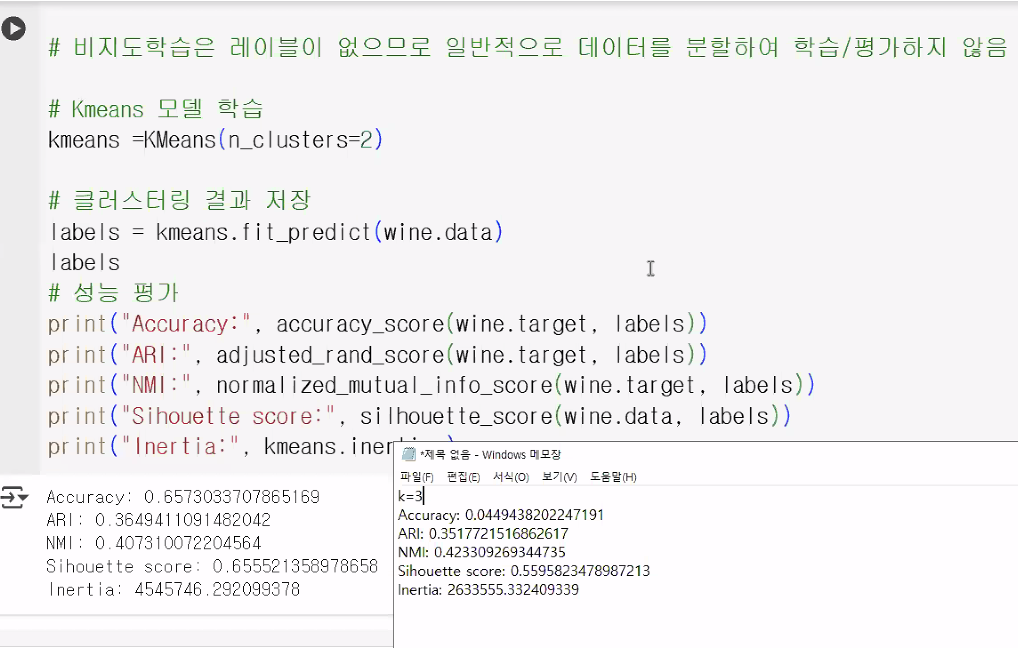

#[실습] digits 데이터를 기반으로 클러스터링
- 최적의 K 찾기

In [58]:
from sklearn.datasets import load_digits
# load_digits 손글씨 데이터
# sklearn사이트에서 찾을 수 있음

digits = load_digits()

print(digits.feature_names, digits.data[:1])
# print(digits.target[:5])
print(digits.DESCR)

['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3', 'pixel_1_4', 'pixel_1_5', 'pixel_1_6', 'pixel_1_7', 'pixel_2_0', 'pixel_2_1', 'pixel_2_2', 'pixel_2_3', 'pixel_2_4', 'pixel_2_5', 'pixel_2_6', 'pixel_2_7', 'pixel_3_0', 'pixel_3_1', 'pixel_3_2', 'pixel_3_3', 'pixel_3_4', 'pixel_3_5', 'pixel_3_6', 'pixel_3_7', 'pixel_4_0', 'pixel_4_1', 'pixel_4_2', 'pixel_4_3', 'pixel_4_4', 'pixel_4_5', 'pixel_4_6', 'pixel_4_7', 'pixel_5_0', 'pixel_5_1', 'pixel_5_2', 'pixel_5_3', 'pixel_5_4', 'pixel_5_5', 'pixel_5_6', 'pixel_5_7', 'pixel_6_0', 'pixel_6_1', 'pixel_6_2', 'pixel_6_3', 'pixel_6_4', 'pixel_6_5', 'pixel_6_6', 'pixel_6_7', 'pixel_7_0', 'pixel_7_1', 'pixel_7_2', 'pixel_7_3', 'pixel_7_4', 'pixel_7_5', 'pixel_7_6', 'pixel_7_7'] [[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
  15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
   0.  9.  8.  0.  

### 나

In [91]:
# K-means 모델 학습
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)
kmeans.fit(digits.data)

KMeans(n_clusters=10)

In [78]:
# 만들어낸 라벨 확인
labels = kmeans.labels_
print(labels)

[8 6 6 ... 6 2 5]


In [92]:
labels = kmeans.predict(digits.data)
print(labels)

[5 2 2 ... 2 0 0]


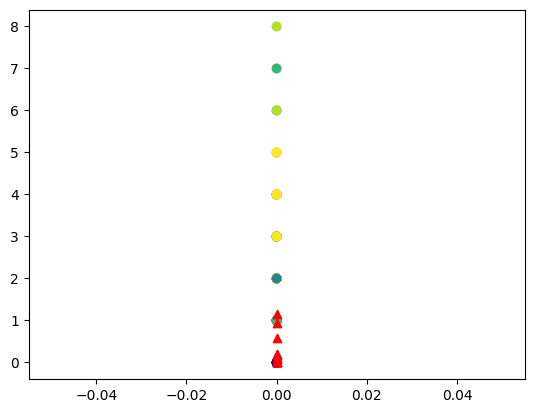

In [93]:
# 학습된 결과 시각화
# 세모가 중심점
plt.scatter(digits.data[:,0], digits.data[:,1], c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1], c='r', marker='^')

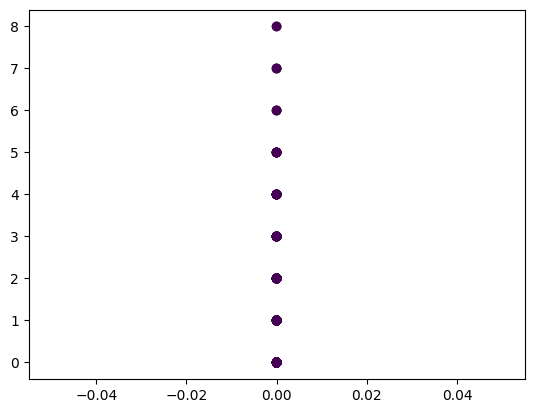

In [96]:
from sklearn.cluster import DBSCAN
# DBSCAN 모델 학습
dbscan = DBSCAN()
labels = dbscan.fit_predict(digits.data)

# DBSCAN 결과 시각화
plt.scatter(X[:,0], X[:,1], c=labels)

In [88]:
# StandardScaler를 이용하여 표준화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
digits_scaled = scaler.fit_transform(digits.data)

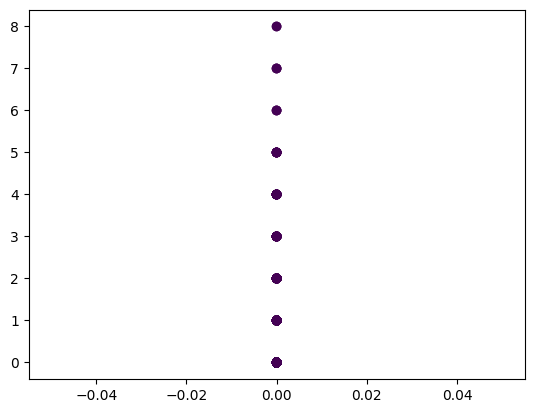

In [89]:
# 표준화된 데이터 클러스터링 및 시각화
z_labels = dbscan.fit_predict(digits_scaled)
plt.scatter(digits.data[:,0], X[:,1], c=z_labels)

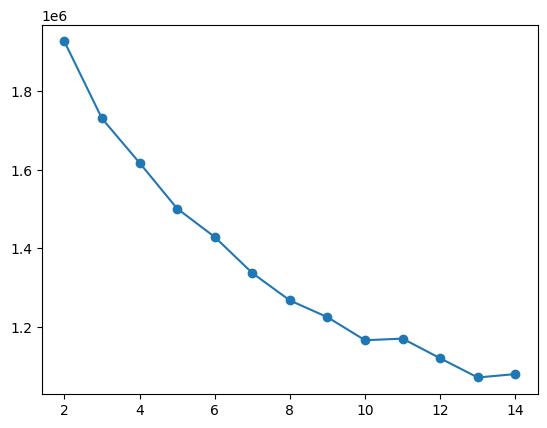

In [97]:
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from sklearn.metrics.cluster import *

# Inertia 기반 적정 K 찾기 (작을수록 데이터가 중심에 가까워 잘 뭉쳐졌다는 의미)
k_range = range(2,15)
inertias = []
for k in k_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(digits.data)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, marker='o')

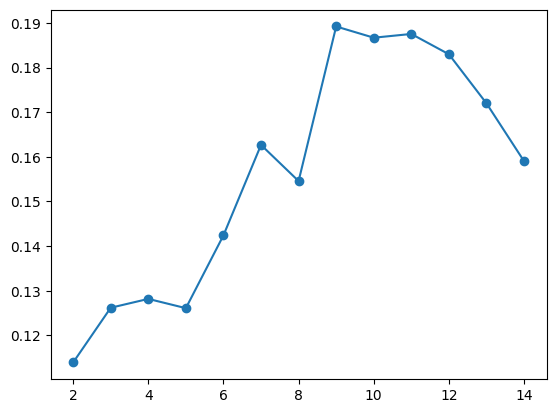

In [98]:
# 실루엣 스코어 기반 적정 K 찾기
s_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k)
    labels = kmeans.fit_predict(digits.data)
    s_scores.append(silhouette_score(digits.data, labels))

plt.plot(k_range, s_scores, marker='o')

### 강사님

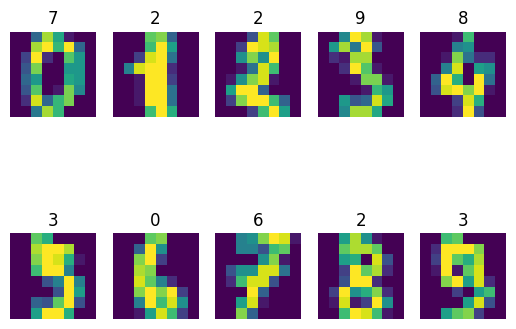

In [102]:
# KMeans
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters = 10)
labels = kmeans.fit_predict(digits.data)

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(digits.images[i])
  plt.title(labels[i])
  plt.axis('off')

# 잘 분리하는 것으로 보이진 않는다.

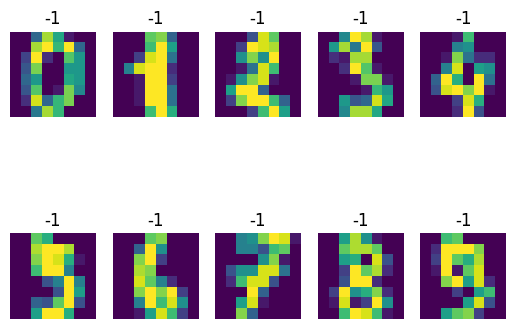

In [103]:
# KMeans
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.1)
labels = dbscan.fit_predict(digits.data)

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(digits.images[i])
  plt.title(labels[i])
  plt.axis('off')

# 다 -1이 나옴 scaler를 통한다면?

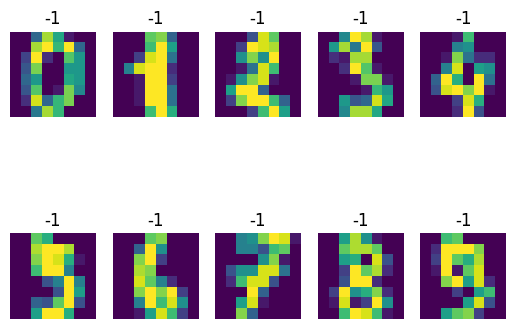

In [104]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(digits.data)
dbscan = DBSCAN(eps=0.1)
labels = dbscan.fit_predict(X_scaled)

for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(digits.images[i])
  plt.title(labels[i])
  plt.axis('off')

# scaler를 써도 다 -1로 노이즈라고 판별

In [111]:
# 적정 K
from sklearn.metrics.cluster import *

inertias = []
s_scores = []
ari = []
nmi = []

for k in range(2,15):
    kmeans = KMeans(n_clusters=k, random_state=0) #random_state=0 으로 정해주면 실행할 때 마다 같은 코드 동일한 그림이 나옴
    kmeans.fit(digits.data)
    inertias.append(kmeans.inertia_)
    s_scores.append(silhouette_score(digits.data, kmeans.labels_))
    ari.append(adjusted_rand_score(digits.target,kmeans.labels_)) # kmeans.labels_ 예측한 클러스터링 값
    nmi.append(normalized_mutual_info_score(digits.target,kmeans.labels_))

Text(0.5, 1.0, 'nmi')

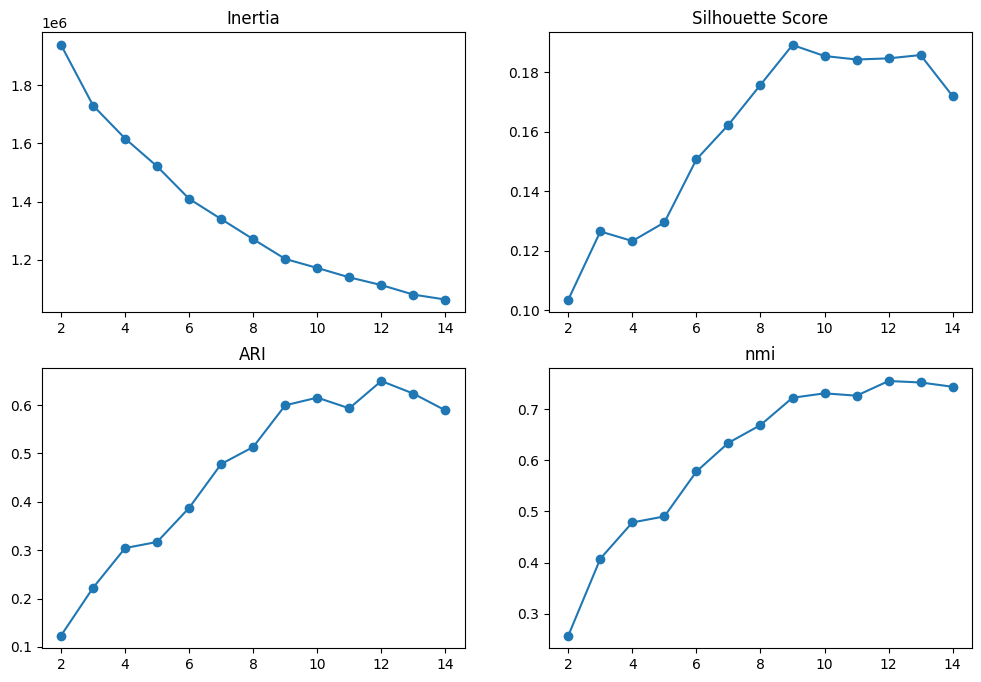

In [112]:
# K별 시각화
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(range(2,15), inertias,marker='o')
plt.title('Inertia')

plt.subplot(2,2,2)
plt.plot(range(2,15), s_scores,marker='o')
plt.title('Silhouette Score')  # 9-13

plt.subplot(2,2,3)
plt.plot(range(2,15), ari,marker='o')
plt.title('ARI') # 12

plt.subplot(2,2,4)
plt.plot(range(2,15), nmi,marker='o')
plt.title('nmi') # 12

# Feature Engineering
- 과대적합과 편향을 방지하기 위해서 필요한 과정으로 데이터에 대한 도메인 지식을 활용하여 특성(Feature)를 만들어내는 과정
    - 불필요한 요소들이 분석에 사용되는 경우 과대적합 발생
    - 부정확한 정보들이 분석에 사용되는 경우 편향 발생
- 주요 Feature Engineering 기법
    - 스케일링(Scaling)
    - 변형(Transform)
    - 부호화(Encoding)
    - 차원 축소(Dimension Reduction)
    - 특성 선택(Feature Selection)
    - 특성 추출(Feature Extraction)
    
    

### 스케일링(Scaling)
- 데이터의 스케일(범위)에 영향이 큰 데이터에 대하여 스케일링을 통해 데이어의 범위를 일정하게 맞춤
    - 표준화(`StandardScaler`), 정규화(`MinMaxScaler`, `Normalizer`)를 주로 사용
    - 새로운 데이터에 대해 예측하고자 하기 때문에 학습 데이터만 변환 학습

### 변형(Transform)
- 다항 변환(`PolynomialFeatures`) : 선형회귀 모델에 도움
- Linear Model은 각 특성의 스케일과 분포에 영향을 받음
    - 각 특성이 정규 분포와 비슷할 때 최고의 성능을 냄
        - 균등분포 변환 (`QuantileTransformer`)
        - 정규분포 변환 (`PowerTransformer`)
        - 수학함수(log, exp, sin 등) : 데이터의 분포를 조정하거나, 비선형적인 특성을 강조하여 모델 성능 개선  


### 부호화(Encoding)
- 범주형 데이터에 대하여 변환하는 방법
    - One-Hot Encoding(`OneHotEncoder`): 고유 값에 해당하는 컬럼에 1표시, 나머지에는 0을 표시하여 배열로 변환
    - 정수형 변환(`OrdinalEncoder`) : 범주의 순서가 중요할때 사용
    - 종속변수에 기반한 변환(`TargetEncoder`) : 범주형 데이터를 종속변수의 평균 등으로 변환, 회귀분석 시 용이




### 차원축소(Dimension Reduction)
- 특성의 변환을 통해 새로운 특성을 추출
    - 특성 간 상관관계 고려 가능, 일반적으로 특성의 개수를 많이 줄일 수 있지만 추출된 특성의 해석이 어려움
    - 주성분 분석(PCA, `decomposition.PCA`)


### 특성 선택(Feature Selection)
- 분석 목적에 부합하는 유의미한 특성만 사용
- 선택한 특성에 대해 해석 용이하지만 특성 간 상관관계를 고려하기 어려움
    - `VarianceThreshold(threshold)` : 분산이 일정 기준 이하인 특성을 제거하는 방법
    - `SelectKBest(score_func, k)` : 가장 중요한 K개의 특성을 선택
        - 분류모델: f_classif(기본값), chi2, mutual_info_classif
        - 회귀모델: r_regression, f_regression, mutual_info_regression
    - `RFE(estimator, n_features_to_select)` : 재귀적 특성 제거
        - `estimator` : 학습 모델(모델의 coef_, feature_importances_를 기반으로 특성 제거)
        - `n_features_to_select` : 선택할 특성의 개수

####[예제] 당뇨병 예측 데이터 Feature Selection

In [114]:
# 데이터 추출 및 분할
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()

X_train, X_test, y_train, y_test = train_test_split(diabetes.data,
                                                    diabetes.target,
                                                    test_size=0.3,
                                                    random_state=0)

In [117]:
# 분산에 의한 선택 (VarianceThreshold)
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

print(X_train.var(axis=0))
# [0.00233247 0.00226754 0.00233188 0.00227242 0.0022447  0.00226477
#  0.00232477 0.00239217 0.00241017 0.00260468]
# ValueError: No feature in X meets the variance threshold 0.20000
# 분산이 0.2 이하이다.

selector = VarianceThreshold(threshold = 0.0023)
reg = LinearRegression()
pipe = Pipeline([('selector', selector), ('reg', reg)])
pipe.fit(X_train,y_train)
print("Train Score:", pipe.score(X_train, y_train))
print("Test Score:", pipe.score(X_test,y_test))

[0.00233247 0.00226754 0.00233188 0.00227242 0.0022447  0.00226477
 0.00232477 0.00239217 0.00241017 0.00260468]
Train Score: 0.5271965854932764
Test Score: 0.30938188344185613


In [120]:
# 사용한 특성 이름 확인
import numpy as np
selector.get_support()
#[0.00233247 0.00226754 0.00233188 0.00227242 0.0022447  0.00226477
# 0.00232477 0.00239217 0.00241017 0.00260468]
# 이 순서대로 threshold = 0.0023 이 맞는지 아닌지에 따라 True, False가 출력

# 특성 이름 가져오기
selector_features = np.array(diabetes.feature_names)[selector.get_support()]
selector_features
# 결과에 나온 ['age', 'bmi', 's3', 's4', 's5', 's6'] 기준으로 variance 를 조정했다고 볼 수 있다.

array(['age', 'bmi', 's3', 's4', 's5', 's6'], dtype='<U3')

In [122]:
# 가장 좋은 K개 특성 사용
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(f_regression, k=6)
reg = LinearRegression()
pipe = Pipeline([('selector', selector), ('reg', reg)])
pipe.fit(X_train,y_train)
print("KBest Score:", pipe.score(X_train, y_train))
print("Test Score:", pipe.score(X_test,y_test))

# 위의 결과보다는 좋은 효과를 가져온다
# selector 설정시 k 설정값 고민해보는 게 좋다.

KBest Score: 0.5377458096214509
Test Score: 0.3538453929559201


In [123]:
# RFE 기반 특성 선택
from sklearn.feature_selection import RFE

#RFE 는 모델을 기반으로 가져온다
rfe = RFE(estimator = LinearRegression(), n_features_to_select=6) # 위에도 K=6이었으니 6으로 해보자
rfe.fit(X_train, y_train)
print("RFE Score:", rfe.score(X_train, y_train))
print("Test Score:", rfe.score(X_test,y_test))

# 전체 식에대해 하는 거이기 떄문에 정확도가 조금은 더 높다.

RFE Score: 0.5514990034540774
Test Score: 0.3955438334970075


In [ ]:
#RFE: 내가 학습한 결과중 버릴 것은 버리고 몇개의 특성만 가지고 할 수 있도록 지정해줌
# 나머지 두개는 파악할 특성 몇개를 묶어서 전달하는 방식? 한번 더 읽기

### 특성 추출(Feature extraction)
- 텍스트나 이미지와 같은 데이터를 수치형 데이터로 변환하는 방법
- 텍스트 특성 추출
    - `CountVectorizer(encoding, lowercase, stop_words, analyzer,..)` : 각 단어의 등장 빈도를 세어서 벡터화
        - `encoding` : 텍스트 인코딩 방식
        - `lowercase` : 소문자 변환
        - `stop_words` : 불용어 설정(벡터화하지 않은 단어리스트)
        - `analyzer` : 분할 방법 설정
            - word(기본값), char, char-wb(형태소)
    - `TfidfVectorizer(encoding, lowercase, stop_words, analyzer,..)` : TF-IDF기반 벡터화
        - TF-IDF(Term Frequency-Inverse Document Frequency) : 전체 문서에서 단어t의 중요도 분석 지표<br>
$TF-IDF(t,d) =TF(t,d) * IDF(t)$
        - TF (Term Frequency): 단어가 문서에서 등장하는 빈도 <br>
$TF(t,d) = \frac{문서d의 단어t의 수}{문서d의 전체 단어수}$
        - IDF (Inverse Document Frequency): 전체 문서 중 단어가 들어간 문서의 빈도의 역수<br>
$IDF(t) = log(\frac{전체 문서의 개수}{단어 t가 포함된 문서의 수})$
- 이미지 특성 추출
    - `extract_patches_2d(patch_size)` : 이미지에서 작은 패치들을 추출
        - patch_size : 패치의 크기(높이, 너비)
    - `reconstruct_from_patches_2d(image_size)` : 패치를 이미지로 변환
        - image_size : 이미지의 크기(높이, 너비)


In [129]:
# 텍스트 특성 추출
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "I am very happy to live the house!",
    "Host is a very nice and beautiful lady.",
    "We really enjoyed our stay at her apartment.",
    "It is lovely and comfortable with everything we needed and lots of space for four friends.",
    "We had a very nice stay, I can recommend it for sure",
    "I really recommend it!",
    "This apartment has a perfect location.",
    "The apartment was dirty, and the bathroom had a terrible smell.",
    "The host was unresponsive and did not help us when we had issues with the check-in process.",
    "The location was far from the attractions, and we spent too much time traveling.",
    "The pictures online were misleading, and the place did not look anything like it was advertised.",
    "The bed was uncomfortable, and we barely slept during our stay."
]

# 카운트 기반 벡터화 (stop_words 미사용)
vectorizer = CountVectorizer(lowercase=True)
word_count = vectorizer.fit_transform(documents)
print(vectorizer.get_feature_names_out(), vectorizer.get_feature_names_out().shape) # 78개의 단어
print(word_count.toarray())

['advertised' 'am' 'and' 'anything' 'apartment' 'at' 'attractions'
 'barely' 'bathroom' 'beautiful' 'bed' 'can' 'check' 'comfortable' 'did'
 'dirty' 'during' 'enjoyed' 'everything' 'far' 'for' 'four' 'friends'
 'from' 'had' 'happy' 'has' 'help' 'her' 'host' 'house' 'in' 'is' 'issues'
 'it' 'lady' 'like' 'live' 'location' 'look' 'lots' 'lovely' 'misleading'
 'much' 'needed' 'nice' 'not' 'of' 'online' 'our' 'perfect' 'pictures'
 'place' 'process' 'really' 'recommend' 'slept' 'smell' 'space' 'spent'
 'stay' 'sure' 'terrible' 'the' 'this' 'time' 'to' 'too' 'traveling'
 'uncomfortable' 'unresponsive' 'us' 'very' 'was' 'we' 'were' 'when'
 'with'] (78,)
[[0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0
  0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0
  1 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1
  0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  1 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0

In [130]:
# 카운트 기반 벡터화 (stop_words 사용)
vectorizer_stop = CountVectorizer(stop_words='english', lowercase=True)
word_count_stop = vectorizer_stop.fit_transform(documents)
print(vectorizer_stop.get_feature_names_out(), vectorizer_stop.get_feature_names_out().shape) # 47개
print(word_count_stop.toarray())

['advertised' 'apartment' 'attractions' 'barely' 'bathroom' 'beautiful'
 'bed' 'check' 'comfortable' 'did' 'dirty' 'enjoyed' 'far' 'friends'
 'happy' 'help' 'host' 'house' 'issues' 'lady' 'like' 'live' 'location'
 'look' 'lots' 'lovely' 'misleading' 'needed' 'nice' 'online' 'perfect'
 'pictures' 'place' 'process' 'really' 'recommend' 'slept' 'smell' 'space'
 'spent' 'stay' 'sure' 'terrible' 'time' 'traveling' 'uncomfortable'
 'unresponsive'] (47,)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
  0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0
  0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
  0 0 0 0 1 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

In [ ]:
# 위에 stop_words 사용과 미사용 차이
# stop_words를 사용하면 단어가 몇개 빠진 것을 볼 수 있음
print(vectorizer.get_feature_names_out(), vectorizer.get_feature_names_out().shape) # 78개의 단어
print(vectorizer_stop.get_feature_names_out(), vectorizer_stop.get_feature_names_out().shape) # 47개

In [134]:
# TF-IDF Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(stop_words='english')
# 단어사전 47개만 만들어지고
# 위에서는 그 숫자가 1로 카운트가 되지만
# 여기서는 count가 아니라 계산된 tfidf로 숫자가 변경되어 있다.
# 단어가 속해 있는게 아니라 얼마나 문서에서 중요한지 중요도를 파악할 수 있다.
tfidf = vectorizer_tfidf.fit_transform(documents)
print(vectorizer_tfidf.get_feature_names_out().shape)
print(vectorizer_tfidf.get_feature_names_out())
print(tfidf.toarray())

(47,)
['advertised' 'apartment' 'attractions' 'barely' 'bathroom' 'beautiful'
 'bed' 'check' 'comfortable' 'did' 'dirty' 'enjoyed' 'far' 'friends'
 'happy' 'help' 'host' 'house' 'issues' 'lady' 'like' 'live' 'location'
 'look' 'lots' 'lovely' 'misleading' 'needed' 'nice' 'online' 'perfect'
 'pictures' 'place' 'process' 'really' 'recommend' 'slept' 'smell' 'space'
 'spent' 'stay' 'sure' 'terrible' 'time' 'traveling' 'uncomfortable'
 'unresponsive']
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.57735027 0.         0.         0.57735027
  0.         0.         0.         0.57735027 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.536

In [138]:
# 추출된 특성 기반 군집 분석
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=0)
# kmeans.fit(tfidf.toarray())
print("word count\n", kmeans.fit(word_count.toarray()).labels_)
print("stop word count\n", kmeans.fit(word_count_stop.toarray()).labels_)
print("tfidf\n", kmeans.fit(tfidf.toarray()).labels_)

word count
 [0 0 0 0 0 0 0 0 1 0 1 0]
stop word count
 [0 0 0 0 0 0 0 0 1 0 0 0]
tfidf
 [1 1 0 0 1 0 0 0 1 0 1 0]


In [ ]:
#  CountVectorizer를 사용하여 텍스트 데이터를 벡터화한 후, K-Means를 적용하여 문장을 2개의 그룹으로 군집화
#K-Means(n_clusters=2)를 사용하여 12개의 문장을 두 개의 그룹(클러스터 0, 1) 으로 분류

# 위에서는 조금 오류가 있었지만
# TF-IDF를 사용하면 **"frequent but unimportant words"**의 영향을 줄이고, 실제 의미 있는 단어로 분류 가능
# # TF-IDF 기반 결과가 가장 신뢰도가 높으며, 긍정/부정 리뷰를 더 명확히 구분하는 경향이 있음
# **긍정적인 리뷰(예: 0, 1, 4, 8, 10)**가 클러스터 1에 배정
# **부정적인 리뷰(예: 2, 3, 5, 6, 7, 9, 11)**는 클러스터 0에 배정

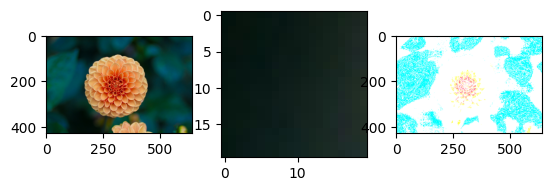

In [142]:
# 이미지 특성 추출
from sklearn.datasets import load_sample_image
from sklearn.feature_extraction import image
import matplotlib.pyplot as plt

flower = load_sample_image('flower.jpg')
plt.subplot(1,3,1)
plt.imshow(flower)

patches = image.extract_patches_2d(flower, patch_size=(20,20))
plt.subplot(1,3,2)
plt.imshow(patches[0])

image_re = image.reconstruct_from_patches_2d(patches, image_size = flower.shape)
plt.subplot(1,3,3)
plt.imshow(image_re)
# 크기는 다시 늘어났지만 rgb가 변하며 색이 좀 변경되어 나옴

In [148]:
# digits 이미지 분할 후 분류분석
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import adjusted_rand_score

digits = load_digits()

km = KMeans(n_clusters=10)
km.fit(digits.data)
km.inertia_

1171680.62363367

In [149]:
from sklearn.feature_extraction.image import PatchExtractor

digits_patches = PatchExtractor(patch_size=(2,2)).fit_transform(digits.images)

km = KMeans(n_clusters=10)
km.fit(digits_patches.reshape(-1,1))
km.inertia_

38314.013570982126

In [ ]:
### 타이타닉 데이터에 대해 feature_engineering